In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# import functions.py

import sys
import os
sys.path.append(os.path.abspath(".."))  # one level up
from functions import * 

In [5]:
# read data of crypto


NAME_CURRENCIES = ["BTC", 'ADA', 'DOGE', 'DOT', 'ETH', 'LTC', 'SOL', 'TRX', 'XLM', 'XRP']
data_dictionary = {name: None for name in NAME_CURRENCIES}
df = pd.read_csv("../data/crypto21to24python.csv")
set(df["symbol"])
n = df.shape[0]//len(NAME_CURRENCIES)
n


1461

## take log difference

In [7]:
cryp_dict = {key: df[df["symbol"] == key][["open", "high", "low", "close"]] for key in NAME_CURRENCIES}


close_matrix = np.zeros([len(NAME_CURRENCIES), n])
open_matrix = np.zeros([len(NAME_CURRENCIES), n])
high_matrix = np.zeros([len(NAME_CURRENCIES), n])
low_matrix = np.zeros([len(NAME_CURRENCIES), n])


for name_idx in range(len(NAME_CURRENCIES)):
    name = NAME_CURRENCIES[name_idx]
    for idx in range(n):
        # print(name)
        close_matrix[name_idx, idx] = cryp_dict[name].iloc[idx]["close"]
        open_matrix[name_idx, idx] = cryp_dict[name].iloc[idx]["open"]
        high_matrix[name_idx, idx] = cryp_dict[name].iloc[idx]["high"]
        low_matrix[name_idx, idx] = cryp_dict[name].iloc[idx]["low"]


close_matrix = np.log(close_matrix[:, 1:]) - np.log(close_matrix[:, :-1])
open_matrix = np.log(open_matrix[:, 1:]) - np.log(open_matrix[:, :-1])
high_matrix = np.log(high_matrix[:, 1:]) - np.log(high_matrix[:, :-1])
low_matrix = np.log(low_matrix[:, 1:]) - np.log(low_matrix[:, :-1])


In [14]:
btc_close = close_matrix[0, :]
rest_close = close_matrix

NUM_SAMPLES = close_matrix.shape[1]
k_list =  list(range(100, 400, 5))  # 60 enties

def q2k(q):
    return int((1 - q) * NUM_SAMPLES)

def k2q(k):
    return 1 - k/NUM_SAMPLES



q_list = [k2q(k) for k in k_list]
q_list

[0.9315068493150684,
 0.928082191780822,
 0.9246575342465754,
 0.9212328767123288,
 0.9178082191780822,
 0.9143835616438356,
 0.910958904109589,
 0.9075342465753424,
 0.904109589041096,
 0.9006849315068494,
 0.8972602739726028,
 0.8938356164383562,
 0.8904109589041096,
 0.886986301369863,
 0.8835616438356164,
 0.8801369863013698,
 0.8767123287671232,
 0.8732876712328768,
 0.8698630136986302,
 0.8664383561643836,
 0.863013698630137,
 0.8595890410958904,
 0.8561643835616438,
 0.8527397260273972,
 0.8493150684931507,
 0.845890410958904,
 0.8424657534246576,
 0.839041095890411,
 0.8356164383561644,
 0.8321917808219178,
 0.8287671232876712,
 0.8253424657534246,
 0.821917808219178,
 0.8184931506849316,
 0.815068493150685,
 0.8116438356164384,
 0.8082191780821918,
 0.8047945205479452,
 0.8013698630136986,
 0.797945205479452,
 0.7945205479452055,
 0.7910958904109588,
 0.7876712328767124,
 0.7842465753424658,
 0.7808219178082192,
 0.7773972602739726,
 0.773972602739726,
 0.7705479452054794,
 0.

## compute $\eta$

In [11]:
eta_results = np.zeros([len(k_list), len(NAME_CURRENCIES), 2])

for k_idx in range(len(k_list)):
    print(k_idx)
    k = k_list[k_idx]
    for i in range(len(NAME_CURRENCIES)):
        eta_results[k_idx, i, 0] = eta(btc_close, rest_close[i, :], k)
        eta_results[k_idx, i, 1] = eta(rest_close[i, :], btc_close, k)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


## compute $\tau$

In [15]:
tau_results = np.zeros([len(k_list), len(NAME_CURRENCIES), 2])

for q_idx in range(len(q_list)):
    print(q_idx)
    q = q_list[q_idx]
    for i in range(len(NAME_CURRENCIES)):
        data = np.stack([btc_close, rest_close[i, :]], axis=1)
        tau_results[q_idx, i, 0] = asymmetric_tail_kendall_tau(data, q, direction='XtoY')
        tau_results[q_idx, i, 1] = asymmetric_tail_kendall_tau(data, q, direction='YtoX')


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


## compute EDM

In [28]:
import numpy as np
from scipy.stats import rankdata

def margin_transform(data):
    """
    data: numpy array of shape (n, 2), where each row is (x_i, y_i)
    Returns: transformed data of shape (n, 2) with margins ~ 1 - 1/(u+1)
    """

    def transform_column(col):
        n = len(col)
        # empirical CDF values (rank/n+1 to avoid 0 or 1)
        u = rankdata(col, method='ordinal') / (n + 1.0)
        # map to target distribution
        return u / (1 - u)

    x = transform_column(data[:, 0])
    y = transform_column(data[:, 1])

    return np.column_stack([x, y])

In [41]:
edm_results = np.zeros([len(k_list), len(NAME_CURRENCIES)])

for k_idx in range(len(k_list)):
    print(k_idx)
    k = k_list[k_idx]
    for i in range(len(NAME_CURRENCIES)):
        data = np.stack([btc_close, rest_close[i, :]], axis=1)
        data = margin_transform(data)
        edm_results[k_idx, i] = edm_estimator(data, k)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


## compare

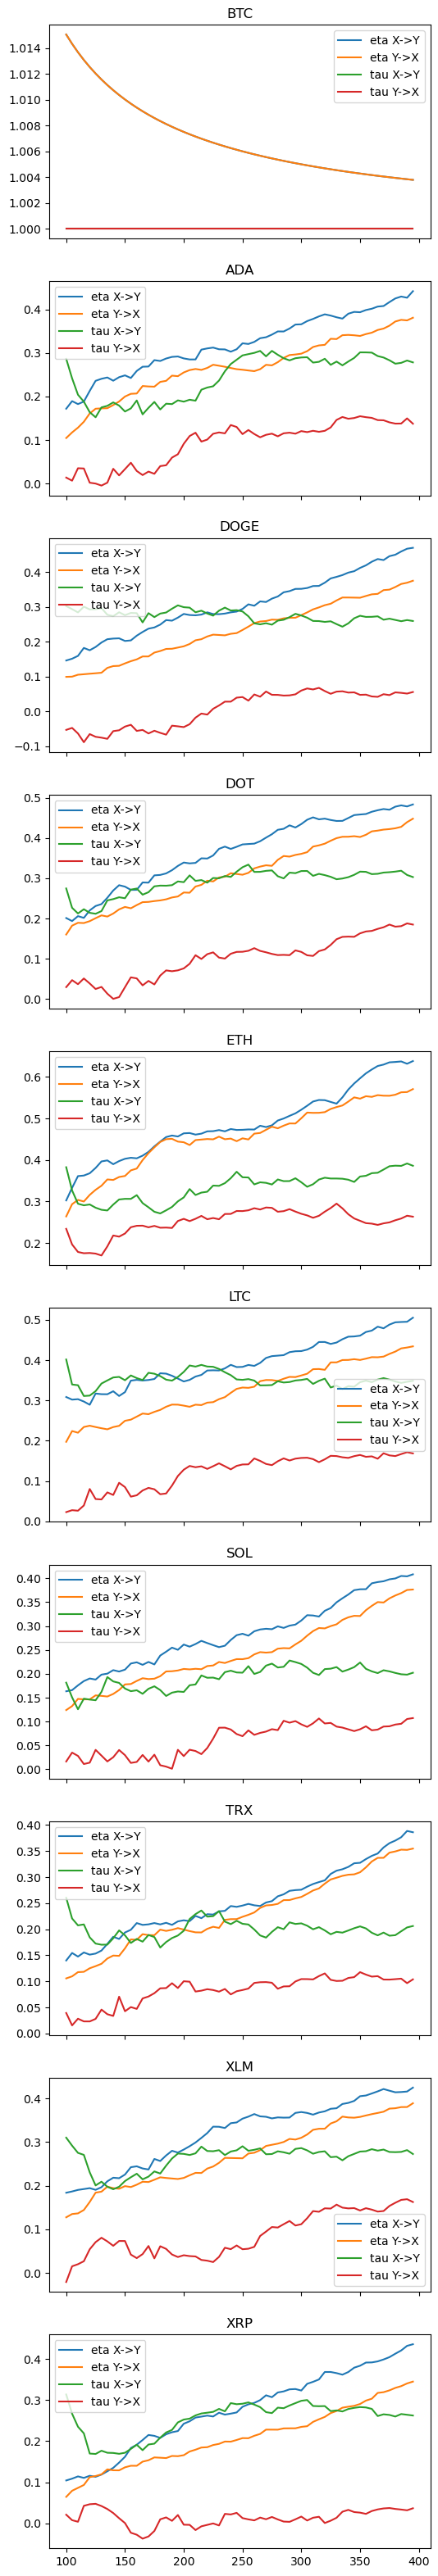

In [42]:
fig, axes = plt.subplots(len(NAME_CURRENCIES), 1, figsize=(6, 4*len(NAME_CURRENCIES)), sharex=True)
for i in range(len(NAME_CURRENCIES)):
    ax = axes[i]
    ax.plot(k_list, eta_results[:, i, 0], label="eta X->Y")
    ax.plot(k_list, eta_results[:, i, 1], label="eta Y->X")
    ax.plot(k_list, tau_results[:, i, 0], label="tau X->Y")
    ax.plot(k_list, tau_results[:, i, 1], label="tau Y->X")
    #ax.plot(range(len(k_list)), edm_results[:, i], label="edm")
    ax.set_title("{}".format(NAME_CURRENCIES[i]))
    ax.legend()